In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")


In [15]:
df = pd.read_csv("../data/olympic_medals.csv")

print(df.shape)
df.head()


(21261, 9)


,season,year,medal,country_code,country,games,sport,event_gender,event_name
0,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,100m
1,Summer,1896,Silver,GER,Germany,1896 Athens,Athletics,Men's,100m
2,Summer,1896,Bronze,HUN,Hungary,1896 Athens,Athletics,Men's,100m
3,Summer,1896,Bronze,USA,United States,1896 Athens,Athletics,Men's,100m
4,Summer,1896,Gold,USA,United States,1896 Athens,Athletics,Men's,400m


In [16]:
df = df.copy()
text_cols = ["season", "medal", "country_code", "country", "games", "sport", "event_gender", "event_name"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year", "country", "sport", "medal"])
df["year"] = df["year"].astype(int)

medal_order = ["Gold", "Silver", "Bronze"]
df["medal"] = pd.Categorical(df["medal"], categories=medal_order, ordered=True)

df.isna().sum()

season          0
year            0
medal           0
country_code    0
country         0
games           0
sport           0
event_gender    0
event_name      0
dtype: int64

In [17]:
missing_cells = int(df.isna().sum().sum())
rows_with_missing = int(df.isna().any(axis=1).sum())
missing_pct = 100 * missing_cells / (df.shape[0] * df.shape[1])

print("Number of entries/medals", f"{len(df):,}"),
print("Number of sports", f"{df['sport'].nunique():,}"),
print("Number of countries", f"{df['country'].nunique():,}"),
print("Missing_data", rows_with_missing)

Number of entries/medals 21,261
Number of sports 92
Number of countries 174
Missing_data 0


In [19]:
summary = pd.Series({
    "year_min": int(df["year"].min()),
    "year_max": int(df["year"].max()),
    "n_games": df["games"].nunique(),
    "n_countries": df["country"].nunique(),
    "n_sports": df["sport"].nunique(),
}, name="value")

print("Dataset summary")
display(summary.to_frame())

print("Medals by type")
display(df["medal"].value_counts().reindex(medal_order))

print("Top 15 countries by total medals")
display(df["country"].value_counts().head(15).to_frame("medals"))

print("Top 15 sports by total medals")
display(df["sport"].value_counts().head(15).to_frame("medals"))


Dataset summary


,value
year_min,1896
year_max,2024
n_games,54
n_countries,174
n_sports,92


Medals by type


Gold      6960
Silver    6927
Bronze    7374
Name: medal, dtype: int64

Top 15 countries by total medals


,medals
United States,3085
USSR,1204
Great Britain,1017
France,959
Germany,955
China,802
Italy,796
Sweden,690
Australia,618
Japan,616


Top 15 sports by total medals


,medals
Athletics,3231
Swimming,1871
Boxing,1035
Gymnastics Artistic,1018
Shooting,907
Rowing,850
Wrestling Freestyle,731
Weightlifting,709
Fencing,704
Judo,652


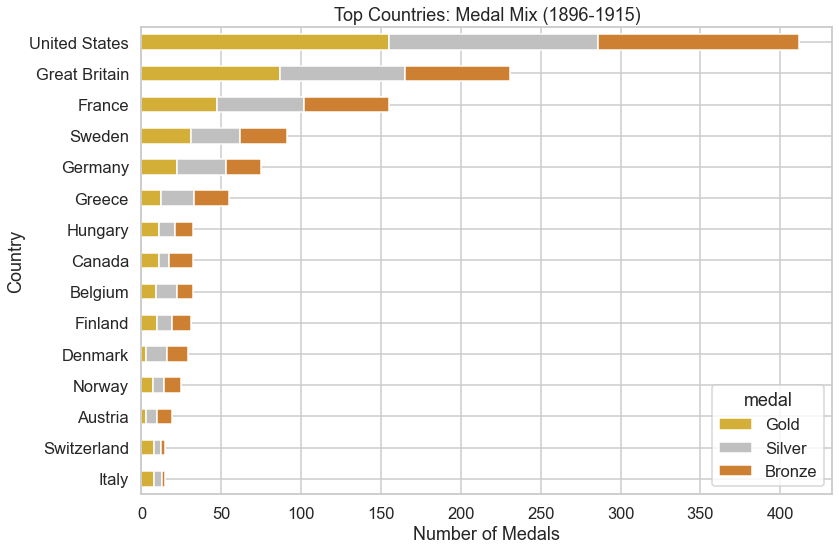

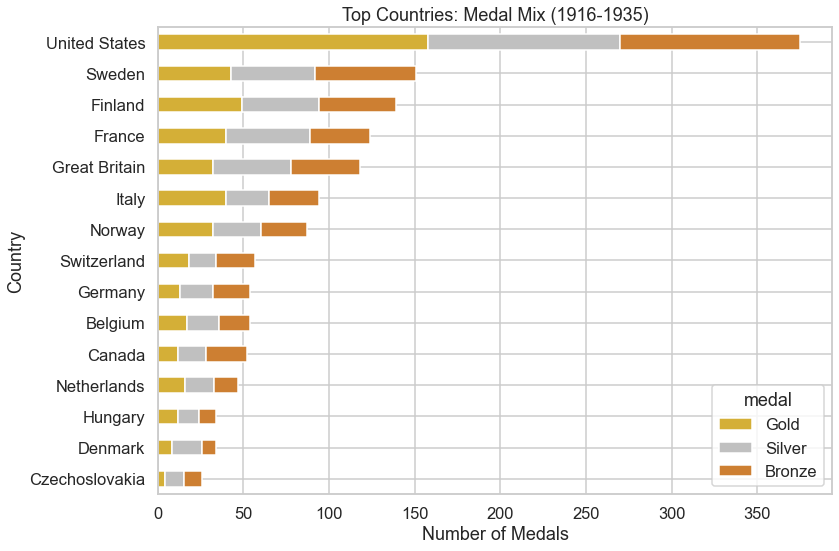

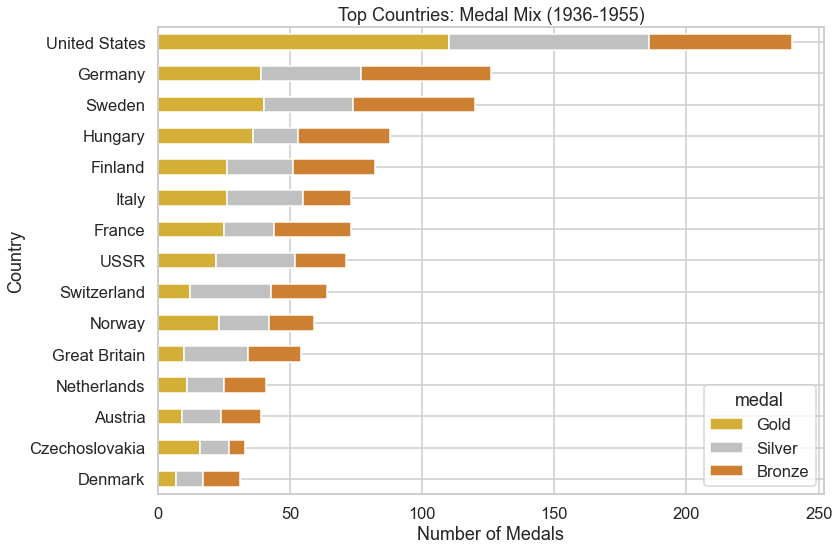

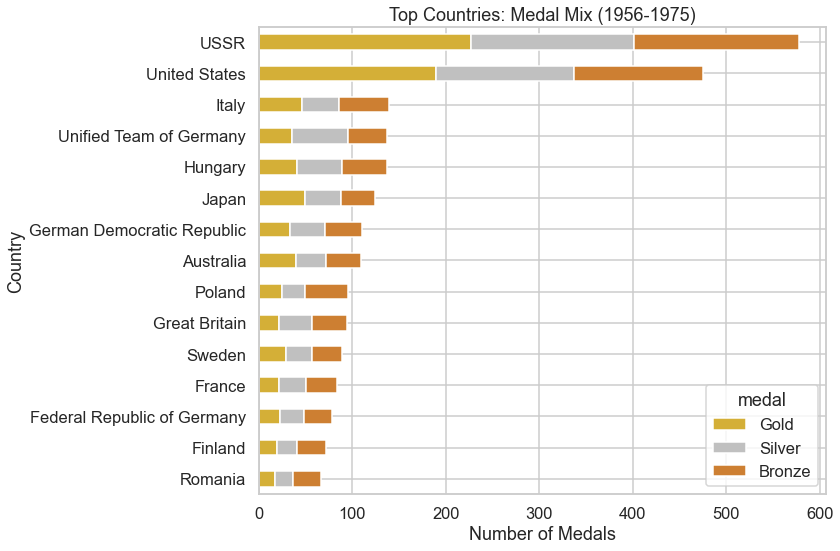

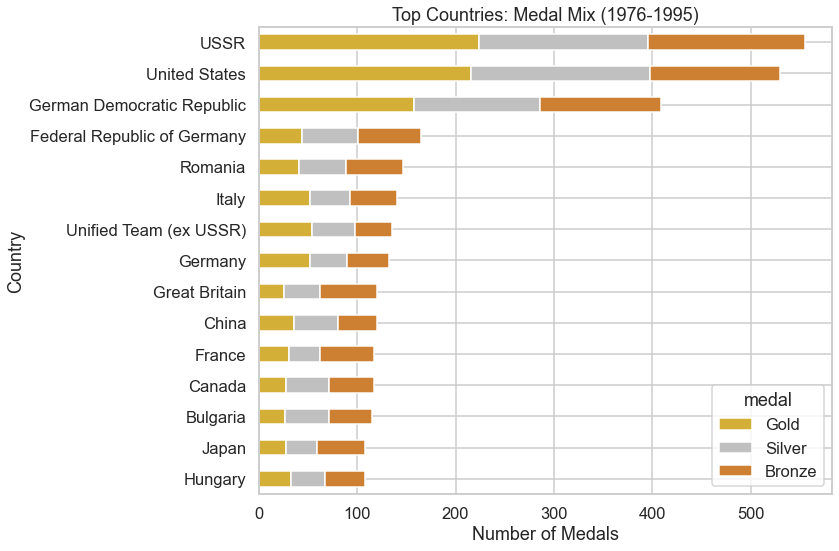

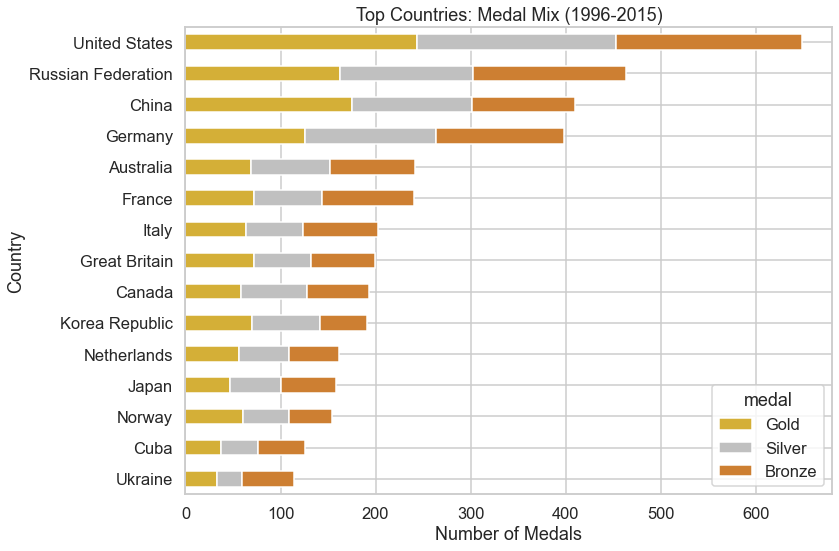

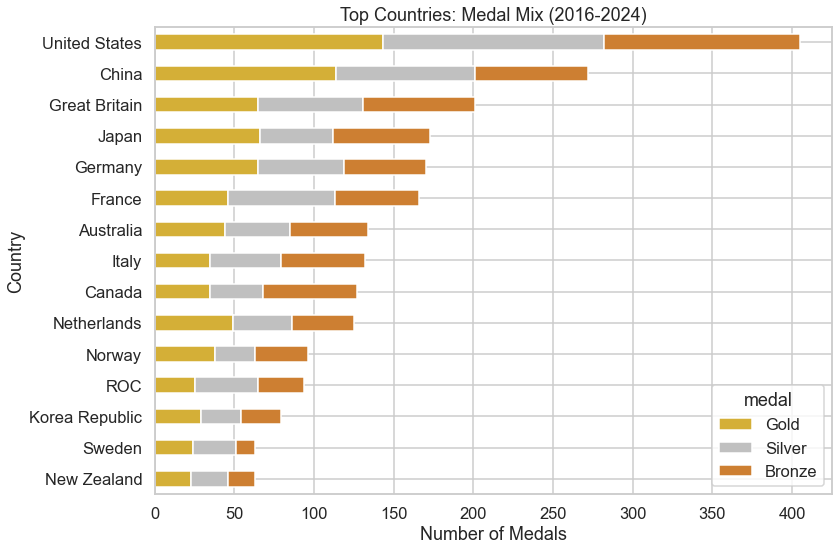

In [5]:
bin_size = 20
min_year = int(df["year"].min())
max_year = int(df["year"].max())

start_year = min_year
end_edge = max_year + 1

bins = np.arange(start_year, end_edge + bin_size, bin_size)
labels = []
for i, b in enumerate(bins[:-1]):
    upper = bins[i + 1] - 1
    if i == len(bins) - 2:
        upper = max_year
    labels.append(f"{b}-{upper}")

df_binned = df.copy()
df_binned["year_bin"] = pd.cut(
    df_binned["year"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

for year_bin, g in df_binned.dropna(subset=["year_bin"]).groupby("year_bin", observed=False):
    if g.empty:
        continue

    top_countries = g["country"].value_counts().head(15).index

    country_medal = (
        g[g["country"].isin(top_countries)]
        .groupby(["country", "medal"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=medal_order, fill_value=0)
    )

    if country_medal.empty:
        continue

    country_medal = country_medal.loc[country_medal.sum(axis=1).sort_values().index]

    ax = country_medal.plot(
        kind="barh",
        stacked=True,
        color=["#d4af37", "#c0c0c0", "#cd7f32"],
        figsize=(12, 8),
    )
    ax.set_title(f"Top Countries: Medal Mix ({year_bin})")
    ax.set_xlabel("Number of Medals")
    ax.set_ylabel("Country")
    plt.tight_layout()
    plt.show()


## Country-Sport Medal Patterns


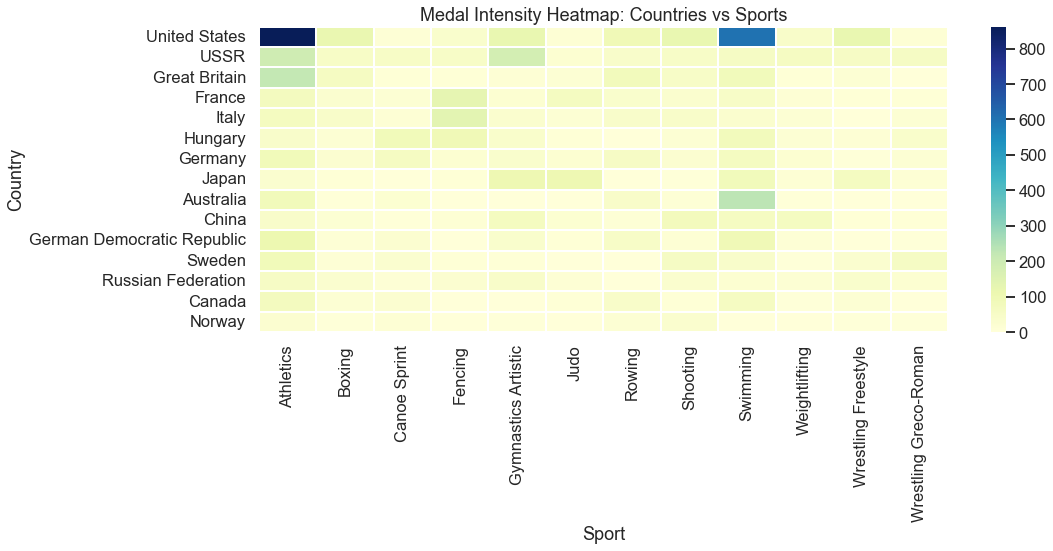

In [22]:
top_country_list = df["country"].value_counts().head(15).index
top_sport_list = df["sport"].value_counts().head(12).index

heatmap_data = (
    df[df["country"].isin(top_country_list) & df["sport"].isin(top_sport_list)]
    .pivot_table(index="country", columns="sport", values="medal", aggfunc="count", fill_value=0)
)

heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.3)
plt.title("Medal Intensity Heatmap: Countries vs Sports")
plt.xlabel("Sport")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


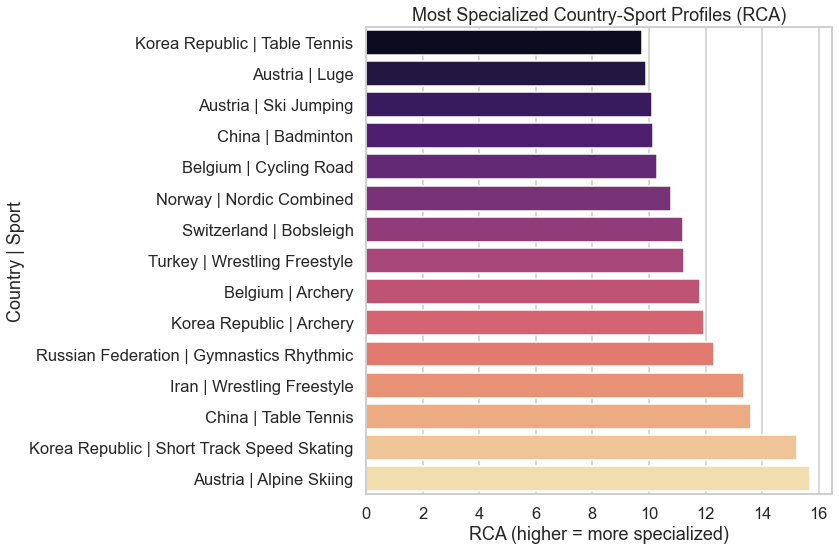

,country,sport,count,country_total,rca
86,Austria,Alpine Skiing,128,351,15.694938
1063,Korea Republic,Short Track Speed Skating,53,379,15.247047
346,China,Table Tennis,59,802,13.600770
892,Iran,Wrestling Freestyle,40,87,13.372329
1416,Russian Federation,Gymnastics Rhythmic,16,542,12.306490
1045,Korea Republic,Archery,46,379,11.946717
159,Belgium,Archery,21,175,11.811667
1678,Turkey,Wrestling Freestyle,41,106,11.249787
1608,Switzerland,Bobsleigh,31,382,11.203696
1251,Norway,Nordic Combined,35,576,10.765842


In [23]:
# Revealed Comparative Advantage (RCA): specialization in a sport relative to global baseline
country_total = df.groupby("country").size()
sport_total = df.groupby("sport").size()
total_medals = len(df)

spec = (
    df.groupby(["country", "sport"]) 
    .size()
    .rename("count")
    .reset_index()
)

spec["country_total"] = spec["country"].map(country_total)
spec["sport_total"] = spec["sport"].map(sport_total)

spec["country_share_in_sport"] = spec["count"] / spec["country_total"]
spec["global_sport_share"] = spec["sport_total"] / total_medals
spec["rca"] = spec["country_share_in_sport"] / spec["global_sport_share"]

# reduce noise from very small countries/sport counts
spec_filtered = spec[(spec["country_total"] >= 80) & (spec["count"] >= 15)]
top_spec = spec_filtered.nlargest(15, "rca").copy()
top_spec["pair"] = top_spec["country"] + " | " + top_spec["sport"]
top_spec = top_spec.sort_values("rca")

plt.figure(figsize=(12, 8))
sns.barplot(data=top_spec, x="rca", y="pair", palette="magma")
plt.title("Most Specialized Country-Sport Profiles (RCA)")
plt.xlabel("RCA (higher = more specialized)")
plt.ylabel("Country | Sport")
plt.tight_layout()
plt.show()

display(top_spec[["country", "sport", "count", "country_total", "rca"]].sort_values("rca", ascending=False))


In [24]:
df['event_gender'].value_counts()

Men's      13202
Women's     6033
Mixed       2026
Name: event_gender, dtype: int64

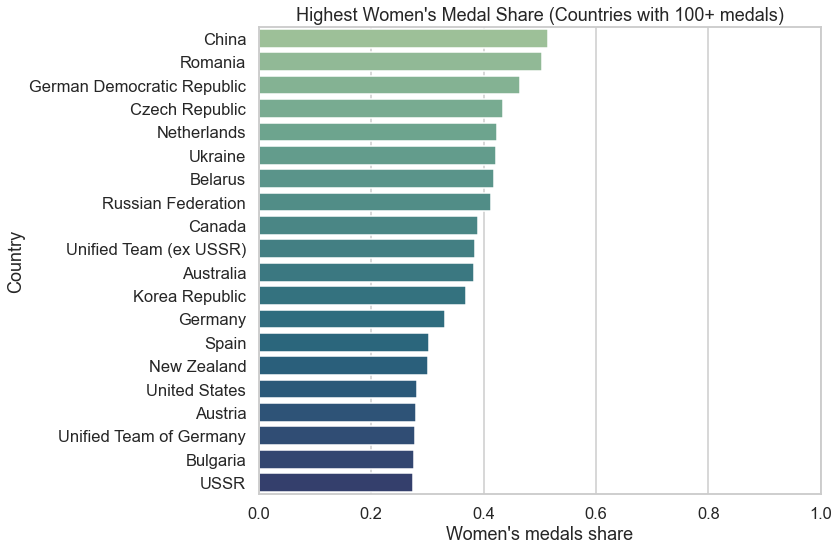

In [25]:
# Gender composition by country (among countries with enough medals)
gender_counts = df.pivot_table(index="country", columns="event_gender", values="medal", aggfunc="count", fill_value=0)
gender_counts["total"] = gender_counts.sum(axis=1)


gender_counts = gender_counts[gender_counts["total"] >= 100].copy()
gender_counts["women_share"] = gender_counts["Women's"] / gender_counts["total"]

women_share = gender_counts.sort_values("women_share", ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=women_share.reset_index(), x="women_share", y="country", palette="crest")
plt.title("Highest Women's Medal Share (Countries with 100+ medals)")
plt.xlabel("Women's medals share")
plt.ylabel("Country")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


/var/folders/wx/dw1r0m8908g82_j2nk9k7fj80000gp/T/ipykernel_88198/2025977562.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=winter_specialists, x="winter_ratio", y="country", palette="Blues_r")


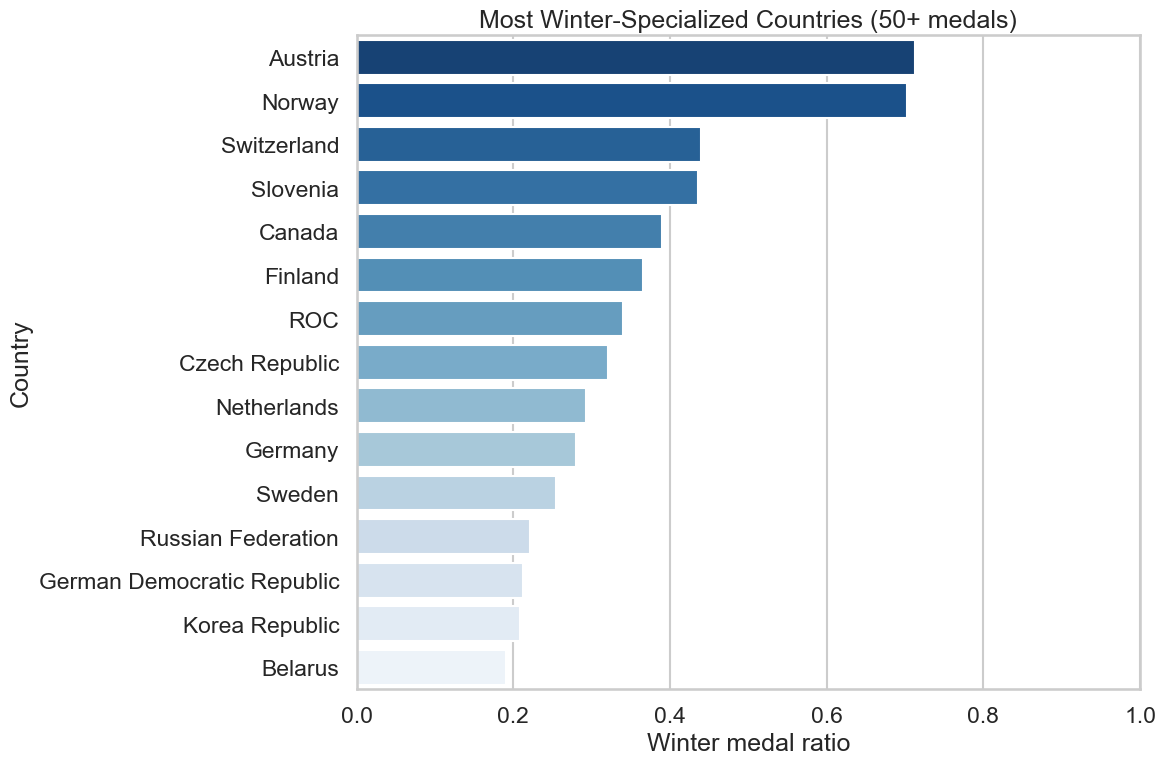

In [7]:
# Summer vs Winter specialization
season_split = df.pivot_table(index="country", columns="season", values="medal", aggfunc="count", fill_value=0)


season_split["total"] = season_split["Summer"] + season_split["Winter"]
season_split = season_split[season_split["total"] >= 50].copy()
season_split["winter_ratio"] = season_split["Winter"] / season_split["total"]

winter_specialists = season_split.sort_values("winter_ratio", ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=winter_specialists, x="winter_ratio", y="country", palette="Blues_r")
plt.title("Most Winter-Specialized Countries (50+ medals)")
plt.xlabel("Winter medal ratio")
plt.ylabel("Country")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
